# RQ5 — Parallel Execution Benchmark
**Research Question:** How does parallel execution of independent pipeline components affect end-to-end latency and throughput?

### What this notebook measures
| Experiment | What it answers |
|---|---|
| 1 — Stage timing | Which stages are slowest? (confirms your latency_report) |
| 2 — Serial vs parallel latency | How much does parallelising config+type save per request? |
| 3 — Concurrent throughput | How many requests/sec at N=1,2,4,8 concurrent users? |
| 4 — Stage-level breakdown | Per-stage timing for serial and parallel side-by-side |

## 0 — Imports and init

In [1]:
import phoenix as px
session = px.launch_app()

/Users/srujanakadambari/anaconda3/envs/thesis/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
/Users/srujanakadambari/anaconda3/envs/thesis/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix


In [2]:
import sys
import os

sys.path.insert(0, "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch")  # ← your actual path here

import time
import json
import statistics
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from retrieve_data import retrieve_data
from init_phoenix import init_phoenix
from prompts.default import (
    DATA_ANALYSIS_PROMPT,
    CHART_CONFIGURATION_PROMPT,
    CREATE_CHART_TYPE_JUSTIFICATION_PROMPT,
    SYSTEM_PROMPT,
)
from response_models.default import (
    DataAnalysis, VisualizationConfig, ChartTypeJustification, ChartType
)
from pydantic import ValidationError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

client, tool_calling_client, tracer = init_phoenix("rq5-parallel-benchmark")
MODEL = "o4-mini"  # or check your helper.py for what model you're actually using
print("Model:", MODEL)


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: rq5-parallel-benchmark
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Model: o4-mini


## 1 — Fixed test data and queries
Five distinct queries on the same dataset — gives variance across question types.

In [3]:
MD_TABLE = retrieve_data(None, type="test")

# 5 queries of varying complexity — used for ALL experiments
QUERIES = [
    "Summarize Umsatz for 2021–2024 and generate a grouped bar chart by month and year.",
    "Show the monthly revenue trend as a line chart and highlight the top 3 peaks.",
    "Compare total annual revenue across 2021, 2022, 2023, 2024 with a bar chart.",
    "Identify the months with the lowest revenue and visualize with annotations.",
    "Plot the full 2021–2024 time series and annotate any months with zero or near-zero revenue.",
]

N_RUNS = 3   # repetitions per query for averaging — increase to 5 for final thesis run
print(f"Queries: {len(QUERIES)}   Repetitions: {N_RUNS}   Total API calls per mode: {len(QUERIES) * N_RUNS}")

Queries: 5   Repetitions: 3   Total API calls per mode: 15


## 2 — Helper: shared LLM call

In [4]:
def call_instructor(model, prompt, response_model):
    result = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_model=response_model,
    )
    if isinstance(result, tuple):
        return result[0]
    return result

def to_dict(x):
    if hasattr(x, "model_dump"): return x.model_dump()
    if hasattr(x, "dict"): return x.dict()
    return x

## 3 — Serial pipeline (baseline)
Runs: analyze → extract_config → justify_type sequentially. 
Records per-stage timing so we can confirm which stage is the bottleneck.

In [5]:
def run_serial(data: str, query: str) -> dict:
    """
    Returns a dict with keys:
      cfg         – the VisualizationConfig dict
      t_analysis  – seconds for data analysis
      t_config    – seconds for chart config extraction
      t_type      – seconds for chart type justification
      t_total     – total wall time
    """
    t0 = time.perf_counter()

    # Stage 1: data analysis
    s = time.perf_counter()
    analysis = to_dict(call_instructor(
        MODEL,
        DATA_ANALYSIS_PROMPT.format(data=data, query=query),
        DataAnalysis
    ))
    t_analysis = time.perf_counter() - s

    # Stage 2: chart config extraction
    s = time.perf_counter()
    cfg = to_dict(call_instructor(
        MODEL,
        CHART_CONFIGURATION_PROMPT.format(data=data, analysis=analysis),
        VisualizationConfig
    ))
    if isinstance(cfg.get("charttype"), ChartType):
        cfg["charttype"] = cfg["charttype"].value
    t_config = time.perf_counter() - s

    # Stage 3: chart type justification
    s = time.perf_counter()
    charttypes = {ct.name for ct in ChartType}
    parsed = call_instructor(
        MODEL,
        CREATE_CHART_TYPE_JUSTIFICATION_PROMPT.format(
            charttypes=charttypes, analysis=analysis, data=data
        ),
        ChartTypeJustification
    )
    chart_type = parsed.chart_type.value if hasattr(parsed, "chart_type") else to_dict(parsed).get("chart_type")
    t_type = time.perf_counter() - s

    cfg["charttype"] = chart_type
    t_total = time.perf_counter() - t0

    return dict(cfg=cfg, t_analysis=t_analysis, t_config=t_config, t_type=t_type, t_total=t_total)

print("Serial pipeline defined.")

Serial pipeline defined.


## 4 — Parallel pipeline
Runs: analyze → [extract_config ∥ justify_type] → merge.
Critical path = max(t_config, t_type) instead of t_config + t_type.

In [6]:
def _extract_config(data, analysis):
    cfg = to_dict(call_instructor(
        MODEL,
        CHART_CONFIGURATION_PROMPT.format(data=data, analysis=analysis),
        VisualizationConfig
    ))
    if isinstance(cfg.get("charttype"), ChartType):
        cfg["charttype"] = cfg["charttype"].value
    return cfg

def _justify_type(data, analysis):
    charttypes = {ct.name for ct in ChartType}
    parsed = call_instructor(
        MODEL,
        CREATE_CHART_TYPE_JUSTIFICATION_PROMPT.format(
            charttypes=charttypes, analysis=analysis, data=data
        ),
        ChartTypeJustification
    )
    return parsed.chart_type.value if hasattr(parsed, "chart_type") else to_dict(parsed).get("chart_type")


def run_parallel(data: str, query: str) -> dict:
    """
    Returns same keys as run_serial, plus:
      t_parallel_wall  – actual wall time of the parallel block (= max of the two futures)
      t_saved          – how much time was saved vs serial (t_config + t_type - t_parallel_wall)
    """
    t0 = time.perf_counter()

    # Stage 1: analysis — unchanged, must be sequential
    s = time.perf_counter()
    analysis = to_dict(call_instructor(
        MODEL,
        DATA_ANALYSIS_PROMPT.format(data=data, query=query),
        DataAnalysis
    ))
    t_analysis = time.perf_counter() - s

    # Stages 2 + 3: run concurrently
    s_parallel = time.perf_counter()
    with ThreadPoolExecutor(max_workers=2) as executor:
        fut_cfg  = executor.submit(_extract_config, data, analysis)
        fut_type = executor.submit(_justify_type,   data, analysis)

        s = time.perf_counter()
        cfg = fut_cfg.result()
        t_config = time.perf_counter() - s  # time we WAITED for config (already running)

        s = time.perf_counter()
        chart_type = fut_type.result()
        t_type = time.perf_counter() - s    # near-zero if type finished before config

    t_parallel_wall = time.perf_counter() - s_parallel

    cfg["charttype"] = chart_type
    t_total = time.perf_counter() - t0

    return dict(
        cfg=cfg,
        t_analysis=t_analysis,
        t_config=t_config,
        t_type=t_type,
        t_parallel_wall=t_parallel_wall,
        t_total=t_total,
    )

print("Parallel pipeline defined.")

Parallel pipeline defined.


## 5 — Experiment 1: Single-request latency (serial vs parallel)
Runs each query N_RUNS times in both modes. Collects per-stage timings.

In [7]:
import os
os.environ["PHOENIX_COLLECTOR_ENDPOINT"] = "http://localhost:6006/"

In [8]:
# Skip Phoenix — use this instead of init_phoenix()
from openai import OpenAI
import instructor
from helper import get_openai_api_key

openai_api = get_openai_api_key()
client = instructor.from_openai(OpenAI())
tool_calling_client = OpenAI(api_key=openai_api["apikey"], base_url=openai_api["baseurl"])

class _Span:
    def __enter__(self): return self
    def __exit__(self, *a): pass
    def set_input(self, **kw): pass
    def set_output(self, **kw): pass
    def set_status(self, *a): pass

class _Tracer:
    def tool(self, fn): return fn
    def chain(self, fn): return fn
    def start_as_current_span(self, *a, **kw): return _Span()

tracer = _Tracer()
print("Ready (no Phoenix)")

Ready (no Phoenix)


In [9]:
serial_results   = []   # list of result dicts
parallel_results = []

for run_idx in range(N_RUNS):
    
    for q_idx, query in enumerate(QUERIES):
        print(f"[Serial]   run={run_idx+1}/{N_RUNS}  query={q_idx+1}/{len(QUERIES)} ...", end=" ", flush=True)
        r = run_serial(MD_TABLE, query)
        r.update(run=run_idx, query_idx=q_idx, mode="serial")
        serial_results.append(r)
        print(f"{r['t_total']:.2f}s")

for run_idx in range(N_RUNS):
    for q_idx, query in enumerate(QUERIES):
        print(f"[Parallel] run={run_idx+1}/{N_RUNS}  query={q_idx+1}/{len(QUERIES)} ...", end=" ", flush=True)
        r = run_parallel(MD_TABLE, query)
        r.update(run=run_idx, query_idx=q_idx, mode="parallel")
        parallel_results.append(r)
        print(f"{r['t_total']:.2f}s")

print("\nDone.")

[Serial]   run=1/3  query=1/5 ... 39.51s
[Serial]   run=1/3  query=2/5 ... 26.15s
[Serial]   run=1/3  query=3/5 ... 38.19s
[Serial]   run=1/3  query=4/5 ... 37.38s
[Serial]   run=1/3  query=5/5 ... 39.67s
[Serial]   run=2/3  query=1/5 ... 35.79s
[Serial]   run=2/3  query=2/5 ... 46.48s
[Serial]   run=2/3  query=3/5 ... 47.77s
[Serial]   run=2/3  query=4/5 ... 35.62s
[Serial]   run=2/3  query=5/5 ... 46.50s
[Serial]   run=3/3  query=1/5 ... 49.02s
[Serial]   run=3/3  query=2/5 ... 41.45s
[Serial]   run=3/3  query=3/5 ... 49.72s
[Serial]   run=3/3  query=4/5 ... 75.42s
[Serial]   run=3/3  query=5/5 ... 39.28s
[Parallel] run=1/3  query=1/5 ... 31.73s
[Parallel] run=1/3  query=2/5 ... 28.69s
[Parallel] run=1/3  query=3/5 ... 41.88s
[Parallel] run=1/3  query=4/5 ... 32.77s
[Parallel] run=1/3  query=5/5 ... 26.82s
[Parallel] run=2/3  query=1/5 ... 38.91s
[Parallel] run=2/3  query=2/5 ... 30.60s
[Parallel] run=2/3  query=3/5 ... 35.67s
[Parallel] run=2/3  query=4/5 ... 35.92s
[Parallel] run=2

In [10]:
# ── Summary statistics ─────────────────────────────────────────────────────────
def summarise(results, label):
    totals = [r["t_total"] for r in results]
    analysis = [r["t_analysis"] for r in results]
    configs  = [r["t_config"]   for r in results]
    types    = [r["t_type"]     for r in results]
    print(f"\n── {label} ──")
    print(f"  Total   : mean={statistics.mean(totals):.2f}s  std={statistics.stdev(totals):.2f}s  "
          f"min={min(totals):.2f}s  max={max(totals):.2f}s")
    print(f"  Analysis: mean={statistics.mean(analysis):.2f}s")
    print(f"  Config  : mean={statistics.mean(configs):.2f}s")
    print(f"  Type    : mean={statistics.mean(types):.2f}s")

summarise(serial_results,   "SERIAL")
summarise(parallel_results, "PARALLEL")

mean_serial   = statistics.mean(r["t_total"] for r in serial_results)
mean_parallel = statistics.mean(r["t_total"] for r in parallel_results)
saving_abs    = mean_serial - mean_parallel
saving_pct    = saving_abs / mean_serial * 100
print(f"\n→ Mean saving: {saving_abs:.2f}s  ({saving_pct:.1f}%)")


── SERIAL ──
  Total   : mean=43.20s  std=10.90s  min=26.15s  max=75.42s
  Analysis: mean=13.38s
  Config  : mean=24.72s
  Type    : mean=5.10s

── PARALLEL ──
  Total   : mean=34.02s  std=7.16s  min=22.31s  max=52.38s
  Analysis: mean=13.76s
  Config  : mean=20.24s
  Type    : mean=0.00s

→ Mean saving: 9.17s  (21.2%)


### Plot 1A — Serial vs parallel total latency (box plot)

/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_73757/3039466382.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


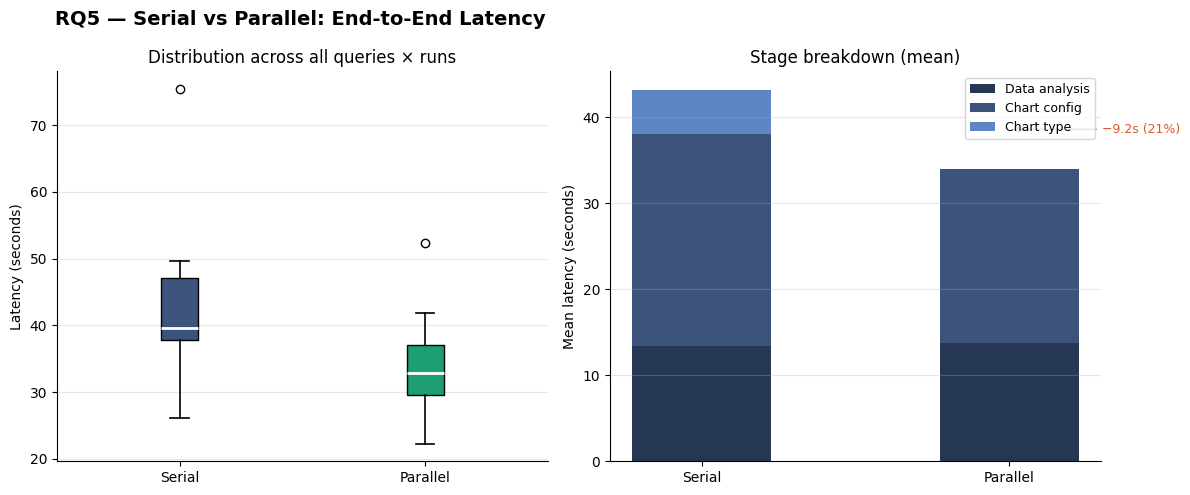

Saved: rq5_latency_comparison.png


In [11]:
serial_totals   = [r["t_total"] for r in serial_results]
parallel_totals = [r["t_total"] for r in parallel_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("RQ5 — Serial vs Parallel: End-to-End Latency", fontsize=14, fontweight="bold", x=0.05, ha="left")

# Box plot
ax = axes[0]
bp = ax.boxplot(
    [serial_totals, parallel_totals],
    labels=["Serial", "Parallel"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
bp["boxes"][0].set_facecolor("#3C547B")
bp["boxes"][1].set_facecolor("#1D9E75")
ax.set_ylabel("Latency (seconds)")
ax.set_title("Distribution across all queries × runs")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Stacked bar: mean per-stage breakdown
ax2 = axes[1]
mean_s = {k: statistics.mean(r[k] for r in serial_results)
          for k in ["t_analysis", "t_config", "t_type"]}
mean_p = {k: statistics.mean(r[k] for r in parallel_results)
          for k in ["t_analysis", "t_config", "t_type"]}

labels = ["Serial", "Parallel"]
analysis_vals = [mean_s["t_analysis"], mean_p["t_analysis"]]
config_vals   = [mean_s["t_config"],   mean_p["t_config"]]
type_vals     = [mean_s["t_type"],     mean_p["t_type"]]

x = np.arange(len(labels))
w = 0.45
b1 = ax2.bar(x, analysis_vals, w, label="Data analysis",  color="#263753")
b2 = ax2.bar(x, config_vals,   w, label="Chart config",   color="#3C547B", bottom=analysis_vals)
b3 = ax2.bar(x, type_vals,     w, label="Chart type",     color="#5E86C5",
             bottom=[a+c for a,c in zip(analysis_vals, config_vals)])

# Annotate totals
for i, (s, p) in enumerate(zip(serial_totals, parallel_totals)):
    pass  # skip per-bar annotation, use summary text below

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Mean latency (seconds)")
ax2.set_title("Stage breakdown (mean)")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

# Annotate saving
ax2.annotate(
    f"−{saving_abs:.1f}s ({saving_pct:.0f}%)",
    xy=(1, mean_parallel + saving_abs / 2),
    xytext=(1.3, mean_parallel + saving_abs / 2),
    arrowprops=dict(arrowstyle="->", color="#D85A30"),
    color="#D85A30", fontsize=9, va="center"
)

plt.tight_layout()
plt.savefig("rq5_latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rq5_latency_comparison.png")

## 6 — Experiment 2: Throughput under concurrent load
Simulates N users sending requests simultaneously.
Measures: total wall time for all N, requests/sec, and mean per-request latency under load.

**Serial baseline:** requests run one after another.  
**Parallel mode:** each request internally parallelises config+type, AND multiple requests overlap.

In [12]:
CONCURRENCY_LEVELS = [1, 2, 4, 8]  # number of simultaneous requests

def run_throughput_experiment(run_fn, concurrency: int, n_requests: int = None) -> dict:
    """
    Fires `concurrency` requests simultaneously, waits for all to complete.
    Returns wall_time, requests_per_sec, individual latencies.
    """
    if n_requests is None:
        n_requests = concurrency  # one batch = one round

    # Each request gets a different query to avoid cache effects
    jobs = [(MD_TABLE, QUERIES[i % len(QUERIES)]) for i in range(n_requests)]

    individual_latencies = []
    wall_start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=concurrency) as pool:
        futures = {pool.submit(run_fn, d, q): i for i, (d, q) in enumerate(jobs)}
        for fut in as_completed(futures):
            result = fut.result()
            individual_latencies.append(result["t_total"])

    wall_time = time.perf_counter() - wall_start
    rps = n_requests / wall_time

    return dict(
        concurrency=concurrency,
        wall_time=wall_time,
        requests_per_sec=rps,
        mean_latency=statistics.mean(individual_latencies),
        individual_latencies=individual_latencies,
    )

print("Throughput experiment defined.")
print(f"Will test concurrency levels: {CONCURRENCY_LEVELS}")
print(f"Total API calls: {sum(CONCURRENCY_LEVELS) * 2} (serial + parallel)")

Throughput experiment defined.
Will test concurrency levels: [1, 2, 4, 8]
Total API calls: 30 (serial + parallel)


In [13]:
throughput_serial   = []
throughput_parallel = []

for c in CONCURRENCY_LEVELS:
    print(f"\n── Concurrency = {c} ──")

    print(f"  Serial   ...", end=" ", flush=True)
    # Serial: no internal parallelism, but requests sent concurrently to test server-side queuing
    r_s = run_throughput_experiment(run_serial, concurrency=c)
    throughput_serial.append(r_s)
    print(f"wall={r_s['wall_time']:.2f}s  RPS={r_s['requests_per_sec']:.3f}")

    print(f"  Parallel ...", end=" ", flush=True)
    r_p = run_throughput_experiment(run_parallel, concurrency=c)
    throughput_parallel.append(r_p)
    print(f"wall={r_p['wall_time']:.2f}s  RPS={r_p['requests_per_sec']:.3f}")

print("\nDone.")


── Concurrency = 1 ──
  Serial   ... wall=33.93s  RPS=0.029
  Parallel ... wall=41.06s  RPS=0.024

── Concurrency = 2 ──
  Serial   ... wall=50.21s  RPS=0.040
  Parallel ... wall=58.46s  RPS=0.034

── Concurrency = 4 ──
  Serial   ... wall=71.44s  RPS=0.056
  Parallel ... wall=51.49s  RPS=0.078

── Concurrency = 8 ──
  Serial   ... 

/Users/srujanakadambari/anaconda3/envs/thesis/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `list[float]` - serialized value may not be as expected [field_name='x_data', input_value='Array for data on x-Axis', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `list[float]` - serialized value may not be as expected [field_name='x_data', input_value='Array for data on x-Axis', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `list[float]` - serialized value may not be as expected [field_name='x_data', input_value='Array for data on x-Axis', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `list[float]` - serialized value may not be as expected [field_name='x_data', input_value='Array for data on x-Axis', input_type=str])
  return self.__pydantic_serializer__.to_python(


wall=58.84s  RPS=0.136
  Parallel ... wall=52.81s  RPS=0.151

Done.


### Plot 2A — Throughput (req/s) vs concurrency level

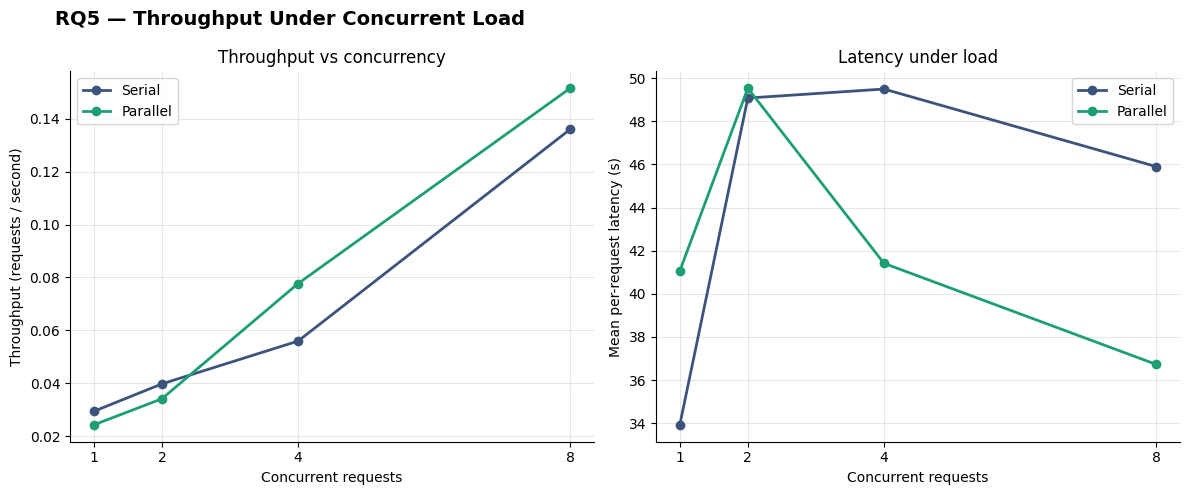

Saved: rq5_throughput.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("RQ5 — Throughput Under Concurrent Load", fontsize=14, fontweight="bold", x=0.05, ha="left")

levels = CONCURRENCY_LEVELS
rps_serial   = [r["requests_per_sec"] for r in throughput_serial]
rps_parallel = [r["requests_per_sec"] for r in throughput_parallel]
lat_serial   = [r["mean_latency"] for r in throughput_serial]
lat_parallel = [r["mean_latency"] for r in throughput_parallel]

# Plot 1: Req/s
ax = axes[0]
ax.plot(levels, rps_serial,   "o-", color="#3C547B", linewidth=2, label="Serial")
ax.plot(levels, rps_parallel, "o-", color="#1D9E75", linewidth=2, label="Parallel")
ax.set_xlabel("Concurrent requests")
ax.set_ylabel("Throughput (requests / second)")
ax.set_title("Throughput vs concurrency")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(levels)

# Plot 2: Mean per-request latency under load
ax2 = axes[1]
ax2.plot(levels, lat_serial,   "o-", color="#3C547B", linewidth=2, label="Serial")
ax2.plot(levels, lat_parallel, "o-", color="#1D9E75", linewidth=2, label="Parallel")
ax2.set_xlabel("Concurrent requests")
ax2.set_ylabel("Mean per-request latency (s)")
ax2.set_title("Latency under load")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_xticks(levels)

plt.tight_layout()
plt.savefig("rq5_throughput.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rq5_throughput.png")

## 7 — Experiment 3: Stage-level Gantt (single request)
Shows the actual timeline of each stage, side by side for serial and parallel.
This is the most intuitive diagram for the thesis.

In [15]:
def run_timed_serial(data, query):
    """Like run_serial but records absolute start/end for Gantt."""
    t0 = time.perf_counter()
    stages = []

    s = time.perf_counter() - t0
    analysis = to_dict(call_instructor(
        MODEL, DATA_ANALYSIS_PROMPT.format(data=data, query=query), DataAnalysis
    ))
    stages.append(("Data analysis", s, time.perf_counter() - t0))

    s = time.perf_counter() - t0
    cfg = to_dict(call_instructor(
        MODEL, CHART_CONFIGURATION_PROMPT.format(data=data, analysis=analysis), VisualizationConfig
    ))
    stages.append(("Chart config", s, time.perf_counter() - t0))

    s = time.perf_counter() - t0
    charttypes = {ct.name for ct in ChartType}
    call_instructor(
        MODEL,
        CREATE_CHART_TYPE_JUSTIFICATION_PROMPT.format(charttypes=charttypes, analysis=analysis, data=data),
        ChartTypeJustification
    )
    stages.append(("Chart type", s, time.perf_counter() - t0))

    return stages


def run_timed_parallel(data, query):
    """Like run_parallel but records absolute start/end for Gantt."""
    t0 = time.perf_counter()
    stages = []
    stage_times = {}

    s = time.perf_counter() - t0
    analysis = to_dict(call_instructor(
        MODEL, DATA_ANALYSIS_PROMPT.format(data=data, query=query), DataAnalysis
    ))
    stages.append(("Data analysis", s, time.perf_counter() - t0))

    def timed_config():
        s = time.perf_counter()
        r = _extract_config(data, analysis)
        return r, time.perf_counter() - s

    def timed_type():
        s = time.perf_counter()
        r = _justify_type(data, analysis)
        return r, time.perf_counter() - s

    par_start = time.perf_counter() - t0
    with ThreadPoolExecutor(max_workers=2) as ex:
        f_cfg  = ex.submit(timed_config)
        f_type = ex.submit(timed_type)
        (cfg, dur_cfg)   = f_cfg.result()
        (ctype, dur_type) = f_type.result()

    stages.append(("Chart config (∥)",  par_start, par_start + dur_cfg))
    stages.append(("Chart type (∥)",    par_start, par_start + dur_type))
    return stages


print("Running single timed request for Gantt chart ...")
gantt_serial   = run_timed_serial(MD_TABLE, QUERIES[0])
gantt_parallel = run_timed_parallel(MD_TABLE, QUERIES[0])
print("Done.")

Running single timed request for Gantt chart ...
Done.


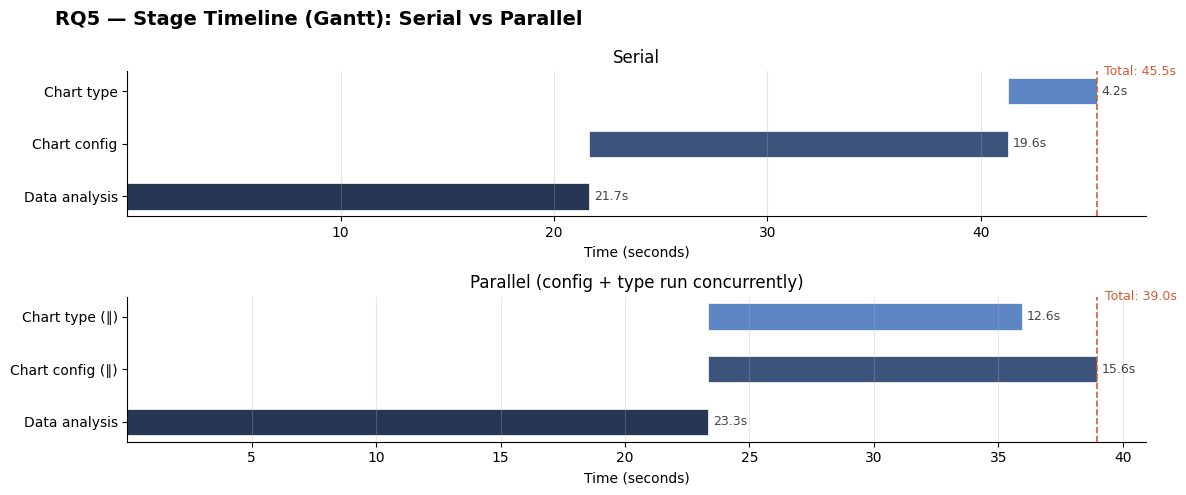

Saved: rq5_gantt.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)
fig.suptitle("RQ5 — Stage Timeline (Gantt): Serial vs Parallel", fontsize=14, fontweight="bold", x=0.05, ha="left")

COLORS = {
    "Data analysis":     "#263753",
    "Chart config":      "#3C547B",
    "Chart type":        "#5E86C5",
    "Chart config (∥)": "#3C547B",
    "Chart type (∥)":   "#5E86C5",
}

def draw_gantt(ax, stages, title):
    y_pos = {name: i for i, (name, _, _) in enumerate(stages)}
    for name, start, end in stages:
        ax.barh(name, end - start, left=start, color=COLORS.get(name, "#888"),
                edgecolor="white", linewidth=0.5, height=0.5)
        ax.text(end + 0.2, name, f"{end - start:.1f}s", va="center", fontsize=9,
                color="#444")
    total = max(end for _, _, end in stages)
    ax.axvline(total, color="#D85A30", linewidth=1.2, linestyle="--")
    ax.text(total + 0.3, len(stages) - 0.5, f"Total: {total:.1f}s",
            color="#D85A30", fontsize=9, va="top")
    ax.set_xlabel("Time (seconds)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

draw_gantt(axes[0], gantt_serial,   "Serial")
draw_gantt(axes[1], gantt_parallel, "Parallel (config + type run concurrently)")

plt.tight_layout()
plt.savefig("rq5_gantt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rq5_gantt.png")

## 8 — Summary table for thesis

In [17]:
rows = []
for c, rs, rp in zip(CONCURRENCY_LEVELS, throughput_serial, throughput_parallel):
    rows.append({
        "Concurrency": c,
        "Serial wall time (s)": round(rs["wall_time"], 2),
        "Parallel wall time (s)": round(rp["wall_time"], 2),
        "Serial RPS": round(rs["requests_per_sec"], 3),
        "Parallel RPS": round(rp["requests_per_sec"], 3),
        "Throughput gain": f"{(rp['requests_per_sec'] / rs['requests_per_sec'] - 1) * 100:.1f}%",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Single request summary
print(f"""
── Single-request latency summary ──────────────────────────────
  Serial   mean: {statistics.mean(r['t_total'] for r in serial_results):.2f}s
  Parallel mean: {statistics.mean(r['t_total'] for r in parallel_results):.2f}s
  Saving       : {saving_abs:.2f}s ({saving_pct:.1f}%)
  Theory       : saving = mean(t_config) + mean(t_type) - max(mean(t_config), mean(t_type))
               = min({statistics.mean(r['t_config'] for r in serial_results):.2f}, "
               {statistics.mean(r['t_type'] for r in serial_results):.2f}) "
               = {min(statistics.mean(r['t_config'] for r in serial_results), statistics.mean(r['t_type'] for r in serial_results)):.2f}s (predicted)
────────────────────────────────────────────────────────────────
""")

df.to_csv("rq5_throughput_results.csv", index=False)
print("Saved: rq5_throughput_results.csv")

 Concurrency  Serial wall time (s)  Parallel wall time (s)  Serial RPS  Parallel RPS Throughput gain
           1                 33.93                   41.06       0.029         0.024          -17.4%
           2                 50.21                   58.46       0.040         0.034          -14.1%
           4                 71.44                   51.49       0.056         0.078           38.8%
           8                 58.84                   52.81       0.136         0.151           11.4%

── Single-request latency summary ──────────────────────────────
  Serial   mean: 43.20s
  Parallel mean: 34.02s
  Saving       : 9.17s (21.2%)
  Theory       : saving = mean(t_config) + mean(t_type) - max(mean(t_config), mean(t_type))
               = min(24.72, "
               5.10) "
               = 5.10s (predicted)
────────────────────────────────────────────────────────────────

Saved: rq5_throughput_results.csv


In [ ]:
# ============================================================
# RQ5 IMPROVED EXPERIMENT
# Serial vs Parallel
# With router and without router
# ============================================================

import os
import sys
import time
import json
import statistics
import pandas as pd
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# ------------------------------------------------------------
# 0. Project path
# CHANGE THIS to your project root if needed
# ------------------------------------------------------------

PROJECT_ROOT = "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch"
sys.path.insert(0, PROJECT_ROOT)

# ------------------------------------------------------------
# 1. Imports from your project
# ------------------------------------------------------------

from retrieve_data import retrieve_data
from init_phoenix import init_phoenix

from prompts.default import (
    DATA_ANALYSIS_PROMPT,
    CHART_CONFIGURATION_PROMPT,
    CREATE_CHART_TYPE_JUSTIFICATION_PROMPT,
    SYSTEM_PROMPT,
)

from response_models.default import (
    DataAnalysis,
    VisualizationConfig,
    ChartTypeJustification,
    ChartType,
)

# ------------------------------------------------------------
# 2. Init client
# ------------------------------------------------------------

client, tool_calling_client, tracer = init_phoenix("rq5-improved-experiment")

MODEL = "o4-mini"

# ------------------------------------------------------------
# 3. Data and queries
# ------------------------------------------------------------

MD_TABLE = retrieve_data(None, type="test")

QUERIES = [
    "Summarize Umsatz for 2021–2024 and generate a grouped bar chart by month and year.",
    "Show the monthly revenue trend as a line chart and highlight the top 3 peaks.",
    "Compare total annual revenue across 2021, 2022, 2023, 2024 with a bar chart.",
    "Identify the months with the lowest revenue and visualize with annotations.",
    "Plot the full 2021–2024 time series and annotate any months with zero or near-zero revenue.",
]

# Increase to 10 for final thesis run
N_RUNS = 5

TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Analyze the data and generate a visualization",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "The data as a markdown table"},
                    "user_query": {"type": "string", "description": "The users query"},
                },
                "required": ["data", "user_query"],
            },
        },
    }
]

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def to_dict(x):
    if hasattr(x, "model_dump"):
        return x.model_dump()
    if hasattr(x, "dict"):
        return x.dict()
    return x


def call_instructor(model, prompt, response_model):
    result = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_model=response_model,
    )

    if isinstance(result, tuple):
        return result[0]

    return result


def timed_call(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start


# ------------------------------------------------------------
# 5. Individual pipeline stages
# ------------------------------------------------------------

def run_router(data, query):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": query},
    ]

    response = tool_calling_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=TOOLS,
    )

    return response


def analyze_data(data, query):
    prompt = DATA_ANALYSIS_PROMPT.format(data=data, query=query)
    parsed = call_instructor(MODEL, prompt, DataAnalysis)
    return to_dict(parsed)


def extract_chart_config(data, analysis):
    prompt = CHART_CONFIGURATION_PROMPT.format(data=data, analysis=analysis)
    parsed = call_instructor(MODEL, prompt, VisualizationConfig)
    cfg = to_dict(parsed)

    if isinstance(cfg.get("charttype"), ChartType):
        cfg["charttype"] = cfg["charttype"].value
    elif hasattr(cfg.get("charttype"), "value"):
        cfg["charttype"] = cfg["charttype"].value

    return cfg


def justify_chart_type(data, analysis):
    charttypes = {ct.name for ct in ChartType}

    prompt = CREATE_CHART_TYPE_JUSTIFICATION_PROMPT.format(
        charttypes=charttypes,
        analysis=analysis,
        data=data,
    )

    parsed = call_instructor(MODEL, prompt, ChartTypeJustification)

    if hasattr(parsed, "chart_type") and parsed.chart_type is not None:
        if hasattr(parsed.chart_type, "value"):
            return parsed.chart_type.value
        return parsed.chart_type

    d = to_dict(parsed)
    ct = d.get("chart_type")

    if isinstance(ct, ChartType):
        return ct.value

    return ct


# ------------------------------------------------------------
# 6. Four experimental conditions
# ------------------------------------------------------------

def run_serial_without_router(data, query):
    total_start = time.perf_counter()

    analysis, t_analysis = timed_call(analyze_data, data, query)
    cfg, t_config = timed_call(extract_chart_config, data, analysis)
    chart_type, t_type = timed_call(justify_chart_type, data, analysis)

    cfg["charttype"] = chart_type

    total = time.perf_counter() - total_start

    return {
        "condition": "serial_without_router",
        "t_router": 0.0,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": 0.0,
        "t_total": total,
        "charttype": chart_type,
        "success": True,
    }


def run_parallel_without_router(data, query):
    total_start = time.perf_counter()

    analysis, t_analysis = timed_call(analyze_data, data, query)

    parallel_start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=2) as executor:
        future_config = executor.submit(timed_call, extract_chart_config, data, analysis)
        future_type = executor.submit(timed_call, justify_chart_type, data, analysis)

        cfg, t_config = future_config.result()
        chart_type, t_type = future_type.result()

    t_parallel_wall = time.perf_counter() - parallel_start

    cfg["charttype"] = chart_type

    total = time.perf_counter() - total_start

    return {
        "condition": "parallel_without_router",
        "t_router": 0.0,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": t_parallel_wall,
        "t_total": total,
        "charttype": chart_type,
        "success": True,
    }


def run_serial_with_router(data, query):
    total_start = time.perf_counter()

    _, t_router = timed_call(run_router, data, query)
    analysis, t_analysis = timed_call(analyze_data, data, query)
    cfg, t_config = timed_call(extract_chart_config, data, analysis)
    chart_type, t_type = timed_call(justify_chart_type, data, analysis)

    cfg["charttype"] = chart_type

    total = time.perf_counter() - total_start

    return {
        "condition": "serial_with_router",
        "t_router": t_router,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": 0.0,
        "t_total": total,
        "charttype": chart_type,
        "success": True,
    }


def run_parallel_with_router(data, query):
    total_start = time.perf_counter()

    _, t_router = timed_call(run_router, data, query)
    analysis, t_analysis = timed_call(analyze_data, data, query)

    parallel_start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=2) as executor:
        future_config = executor.submit(timed_call, extract_chart_config, data, analysis)
        future_type = executor.submit(timed_call, justify_chart_type, data, analysis)

        cfg, t_config = future_config.result()
        chart_type, t_type = future_type.result()

    t_parallel_wall = time.perf_counter() - parallel_start

    cfg["charttype"] = chart_type

    total = time.perf_counter() - total_start

    return {
        "condition": "parallel_with_router",
        "t_router": t_router,
        "t_analysis": t_analysis,
        "t_config": t_config,
        "t_type": t_type,
        "t_parallel_wall": t_parallel_wall,
        "t_total": total,
        "charttype": chart_type,
        "success": True,
    }


# ------------------------------------------------------------
# 7. Safe wrapper so failed runs are also recorded
# ------------------------------------------------------------

def safe_run(run_fn, data, query):
    try:
        return run_fn(data, query)
    except Exception as e:
        return {
            "condition": run_fn.__name__.replace("run_", ""),
            "t_router": np.nan,
            "t_analysis": np.nan,
            "t_config": np.nan,
            "t_type": np.nan,
            "t_parallel_wall": np.nan,
            "t_total": np.nan,
            "charttype": None,
            "success": False,
            "error": str(e),
        }


# ------------------------------------------------------------
# 8. Execute experiment
# ------------------------------------------------------------

CONDITIONS = [
    run_serial_without_router,
    run_parallel_without_router,
    run_serial_with_router,
    run_parallel_with_router,
]

all_results = []

for run_idx in range(1, N_RUNS + 1):
    for query_idx, query in enumerate(QUERIES, start=1):
        for fn in CONDITIONS:
            print(f"Running {fn.__name__} | run {run_idx}/{N_RUNS} | query {query_idx}/{len(QUERIES)}")

            result = safe_run(fn, MD_TABLE, query)
            result["run"] = run_idx
            result["query_idx"] = query_idx
            result["query"] = query

            all_results.append(result)

            if result["success"]:
                print(f"  success | total = {result['t_total']:.2f}s | charttype = {result['charttype']}")
            else:
                print(f"  failed | error = {result.get('error')}")

# ------------------------------------------------------------
# 9. Save raw results
# ------------------------------------------------------------

df = pd.DataFrame(all_results)
df.to_csv("rq5_improved_raw_results.csv", index=False)

print("\nSaved raw results:")
print("rq5_improved_raw_results.csv")

display(df.head())

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: rq5-improved-experiment
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Running run_serial_without_router | run 1/5 | query 1/5
  success | total = 38.80s | charttype = column
Running run_parallel_without_router | run 1/5 | query 1/5
  success | total = 35.53s | charttype = column
Running run_serial_with_router | run 1/5 | query 1/5
  success | total = 35.61s | charttype = column
Running run_parallel_with_router | run 1/5 | query 1/5
  success | total = 40.82s | charttype = column
Run

In [ ]:
# ============================================================
# RQ5 SUMMARY STATISTICS
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("rq5_improved_raw_results.csv")

valid = df[df["success"] == True].copy()

summary = (
    valid
    .groupby("condition")
    .agg(
        n=("t_total", "count"),
        mean_latency_s=("t_total", "mean"),
        median_latency_s=("t_total", "median"),
        std_latency_s=("t_total", "std"),
        min_latency_s=("t_total", "min"),
        max_latency_s=("t_total", "max"),
        p95_latency_s=("t_total", lambda x: np.percentile(x, 95)),
        mean_router_s=("t_router", "mean"),
        mean_analysis_s=("t_analysis", "mean"),
        mean_config_s=("t_config", "mean"),
        mean_type_s=("t_type", "mean"),
        mean_parallel_wall_s=("t_parallel_wall", "mean"),
    )
    .reset_index()
)

# Round values
for col in summary.columns:
    if col != "condition":
        summary[col] = summary[col].round(2)

summary.to_csv("rq5_improved_summary.csv", index=False)

print("Saved:")
print("rq5_improved_summary.csv")

display(summary)

In [ ]:
# ============================================================
# RQ5 IMPROVEMENT TABLE
# ============================================================

summary = pd.read_csv("rq5_improved_summary.csv")

def get_mean(condition):
    return float(summary.loc[summary["condition"] == condition, "mean_latency_s"].iloc[0])

serial_no_router = get_mean("serial_without_router")
parallel_no_router = get_mean("parallel_without_router")
serial_router = get_mean("serial_with_router")
parallel_router = get_mean("parallel_with_router")

improvement_rows = []

improvement_rows.append({
    "Comparison": "Without router: serial vs parallel",
    "Serial mean latency (s)": serial_no_router,
    "Parallel mean latency (s)": parallel_no_router,
    "Absolute reduction (s)": serial_no_router - parallel_no_router,
    "Relative reduction (%)": ((serial_no_router - parallel_no_router) / serial_no_router) * 100,
})

improvement_rows.append({
    "Comparison": "With router: serial vs parallel",
    "Serial mean latency (s)": serial_router,
    "Parallel mean latency (s)": parallel_router,
    "Absolute reduction (s)": serial_router - parallel_router,
    "Relative reduction (%)": ((serial_router - parallel_router) / serial_router) * 100,
})

improvement_df = pd.DataFrame(improvement_rows)

for col in improvement_df.columns:
    if col != "Comparison":
        improvement_df[col] = improvement_df[col].round(2)

improvement_df.to_csv("rq5_improved_improvement_table.csv", index=False)

print("Saved:")
print("rq5_improved_improvement_table.csv")

display(improvement_df)

In [ ]:
# ============================================================
# RQ5 BOXPLOT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rq5_improved_raw_results.csv")
valid = df[df["success"] == True].copy()

order = [
    "serial_without_router",
    "parallel_without_router",
    "serial_with_router",
    "parallel_with_router",
]

data = [valid.loc[valid["condition"] == c, "t_total"].dropna() for c in order]

labels = [
    "Serial\nNo router",
    "Parallel\nNo router",
    "Serial\nWith router",
    "Parallel\nWith router",
]

plt.figure(figsize=(11, 6))
box = plt.boxplot(data, labels=labels, patch_artist=True)

for median in box["medians"]:
    median.set_linewidth(2)

plt.ylabel("End-to-end latency (seconds)")
plt.title("RQ5 — Serial vs Parallel Latency Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rq5_improved_latency_boxplot.png", dpi=150)
plt.show()

print("Saved:")
print("rq5_improved_latency_boxplot.png")

In [ ]:
# ============================================================
# RQ5 STAGE BREAKDOWN
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

summary = pd.read_csv("rq5_improved_summary.csv")

order = [
    "serial_without_router",
    "parallel_without_router",
    "serial_with_router",
    "parallel_with_router",
]

plot_df = summary.set_index("condition").loc[order].reset_index()

labels = [
    "Serial\nNo router",
    "Parallel\nNo router",
    "Serial\nWith router",
    "Parallel\nWith router",
]

x = np.arange(len(labels))

router = plot_df["mean_router_s"].values
analysis = plot_df["mean_analysis_s"].values
config = plot_df["mean_config_s"].values
chart_type = plot_df["mean_type_s"].values

plt.figure(figsize=(12, 6))

plt.bar(x, router, label="Router")
plt.bar(x, analysis, bottom=router, label="Data analysis")
plt.bar(x, config, bottom=router + analysis, label="Chart config")
plt.bar(x, chart_type, bottom=router + analysis + config, label="Chart type")

plt.xticks(x, labels)
plt.ylabel("Mean stage latency (seconds)")
plt.title("RQ5 — Mean Stage Breakdown")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("rq5_improved_stage_breakdown.png", dpi=150)
plt.show()

print("Saved:")
print("rq5_improved_stage_breakdown.png")

In [ ]:
# ============================================================
# RQ5 CRITICAL PATH COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("rq5_improved_raw_results.csv")
valid = df[df["success"] == True].copy()

rows = []

for condition, group in valid.groupby("condition"):
    rows.append({
        "condition": condition,
        "mean_total": group["t_total"].mean(),
        "mean_router": group["t_router"].mean(),
        "mean_analysis": group["t_analysis"].mean(),
        "mean_config": group["t_config"].mean(),
        "mean_type": group["t_type"].mean(),
        "mean_parallel_wall": group["t_parallel_wall"].mean(),
    })

crit = pd.DataFrame(rows)

def critical_path(row):
    if "parallel" in row["condition"]:
        return row["mean_router"] + row["mean_analysis"] + row["mean_parallel_wall"]
    else:
        return row["mean_router"] + row["mean_analysis"] + row["mean_config"] + row["mean_type"]

crit["estimated_critical_path"] = crit.apply(critical_path, axis=1)

order = [
    "serial_without_router",
    "parallel_without_router",
    "serial_with_router",
    "parallel_with_router",
]

crit = crit.set_index("condition").loc[order].reset_index()

labels = [
    "Serial\nNo router",
    "Parallel\nNo router",
    "Serial\nWith router",
    "Parallel\nWith router",
]

plt.figure(figsize=(10, 6))
plt.bar(labels, crit["mean_total"])

for i, value in enumerate(crit["mean_total"]):
    plt.text(i, value + 0.5, f"{value:.1f}s", ha="center", fontweight="bold")

plt.ylabel("Mean end-to-end latency (seconds)")
plt.title("RQ5 — Critical Path / End-to-End Latency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rq5_improved_critical_path.png", dpi=150)
plt.show()

crit.to_csv("rq5_improved_critical_path.csv", index=False)

print("Saved:")
print("rq5_improved_critical_path.png")
print("rq5_improved_critical_path.csv")

display(crit.round(2))

In [ ]:
# ============================================================
# RQ5 THROUGHPUT UNDER CONCURRENT LOAD
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import statistics
import pandas as pd
import numpy as np

CONCURRENCY_LEVELS = [1, 2, 4, 8]

# To keep cost/time manageable, choose only two main conditions
THROUGHPUT_CONDITIONS = {
    "serial_without_router": run_serial_without_router,
    "parallel_without_router": run_parallel_without_router,
    "serial_with_router": run_serial_with_router,
    "parallel_with_router": run_parallel_with_router,
}

def run_throughput_condition(condition_name, run_fn, concurrency):
    jobs = [(MD_TABLE, QUERIES[i % len(QUERIES)]) for i in range(concurrency)]

    latencies = []
    successes = 0
    failures = 0

    wall_start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=concurrency) as pool:
        futures = [pool.submit(safe_run, run_fn, data, query) for data, query in jobs]

        for fut in as_completed(futures):
            result = fut.result()

            if result["success"]:
                successes += 1
                latencies.append(result["t_total"])
            else:
                failures += 1

    wall_time = time.perf_counter() - wall_start

    return {
        "condition": condition_name,
        "concurrency": concurrency,
        "requests": concurrency,
        "successes": successes,
        "failures": failures,
        "wall_time_s": wall_time,
        "requests_per_second": successes / wall_time if wall_time > 0 else np.nan,
        "mean_latency_s": statistics.mean(latencies) if latencies else np.nan,
        "median_latency_s": statistics.median(latencies) if latencies else np.nan,
        "p95_latency_s": np.percentile(latencies, 95) if latencies else np.nan,
    }


throughput_results = []

for condition_name, run_fn in THROUGHPUT_CONDITIONS.items():
    for concurrency in CONCURRENCY_LEVELS:
        print(f"Throughput test | {condition_name} | concurrency={concurrency}")

        result = run_throughput_condition(condition_name, run_fn, concurrency)
        throughput_results.append(result)

        print(
            f"  wall={result['wall_time_s']:.2f}s | "
            f"RPS={result['requests_per_second']:.3f} | "
            f"mean latency={result['mean_latency_s']:.2f}s"
        )

throughput_df = pd.DataFrame(throughput_results)

for col in throughput_df.columns:
    if throughput_df[col].dtype in ["float64", "float32"]:
        throughput_df[col] = throughput_df[col].round(3)

throughput_df.to_csv("rq5_improved_throughput.csv", index=False)

print("Saved:")
print("rq5_improved_throughput.csv")

display(throughput_df)

In [ ]:
# ============================================================
# RQ5 THROUGHPUT PLOTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

throughput_df = pd.read_csv("rq5_improved_throughput.csv")

plt.figure(figsize=(11, 6))

for condition in throughput_df["condition"].unique():
    subset = throughput_df[throughput_df["condition"] == condition]
    plt.plot(
        subset["concurrency"],
        subset["requests_per_second"],
        marker="o",
        label=condition,
    )

plt.xlabel("Concurrent requests")
plt.ylabel("Throughput / requests per second")
plt.title("RQ5 — Throughput Under Concurrent Load")
plt.xticks(sorted(throughput_df["concurrency"].unique()))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("rq5_improved_throughput_rps.png", dpi=150)
plt.show()

plt.figure(figsize=(11, 6))

for condition in throughput_df["condition"].unique():
    subset = throughput_df[throughput_df["condition"] == condition]
    plt.plot(
        subset["concurrency"],
        subset["mean_latency_s"],
        marker="o",
        label=condition,
    )

plt.xlabel("Concurrent requests")
plt.ylabel("Mean per-request latency (seconds)")
plt.title("RQ5 — Mean Latency Under Concurrent Load")
plt.xticks(sorted(throughput_df["concurrency"].unique()))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("rq5_improved_throughput_latency.png", dpi=150)
plt.show()

print("Saved:")
print("rq5_improved_throughput_rps.png")
print("rq5_improved_throughput_latency.png")